# E-value Distribution: Structure-based vs Sequence-based HMM

Shows the **E-value distributions** for positives and negatives under each model,
demonstrating that the structure-based HMM achieves better separation.

Files expected in `Data/Processed/`:
- `struct_set_1.class`, `struct_set_2.class`
- `seq_set_1.class`, `seq_set_2.class`

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

BASE = '../Data/Processed'

def parse_class(filepath):
    pos_ev, neg_ev = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            label = int(parts[1])
            evalue = float(parts[2])
            if label == 1:
                pos_ev.append(evalue)
            else:
                neg_ev.append(evalue)
    return pos_ev, neg_ev

# Load both folds, combine
sp1, sn1 = parse_class(f'{BASE}/struct_set_1.class')
sp2, sn2 = parse_class(f'{BASE}/struct_set_2.class')
qp1, qn1 = parse_class(f'{BASE}/seq_set_1.class')
qp2, qn2 = parse_class(f'{BASE}/seq_set_2.class')

struct_pos = sp1 + sp2
struct_neg = sn1 + sn2
seq_pos    = qp1 + qp2
seq_neg    = qn1 + qn2

print(f'Structure-based: {len(struct_pos)} positives, {len(struct_neg)} negatives')
print(f'Sequence-based:  {len(seq_pos)} positives, {len(seq_neg)} negatives')

# Key statistics
eps = 1e-320
print(f'\nStructure-based positives: min={min(struct_pos):.2e}  max={max(struct_pos):.2e}')
print(f'Sequence-based positives:  min={min(seq_pos):.2e}  max={max(seq_pos):.2e}')
struct_neg_hits = [e for e in struct_neg if e < 10]
seq_neg_hits    = [e for e in seq_neg if e < 10]
print(f'\nStructure-based negatives with hits (<10): {len(struct_neg_hits)}')
print(f'Sequence-based negatives with hits (<10):  {len(seq_neg_hits)}')
print(f'\nStruct negatives scoring < 1e-5: {sum(1 for e in struct_neg if e <= 1e-5)}')
print(f'Seq negatives scoring < 1e-5:    {sum(1 for e in seq_neg if e <= 1e-5)}')

Structure-based: 211 positives, 574229 negatives
Sequence-based:  211 positives, 574229 negatives

Structure-based positives: min=8.60e-194  max=1.00e+01
Sequence-based positives:  min=1.60e-207  max=1.80e-05

Structure-based negatives with hits (<10): 24
Sequence-based negatives with hits (<10):  4022

Struct negatives scoring < 1e-5: 0
Seq negatives scoring < 1e-5:    4


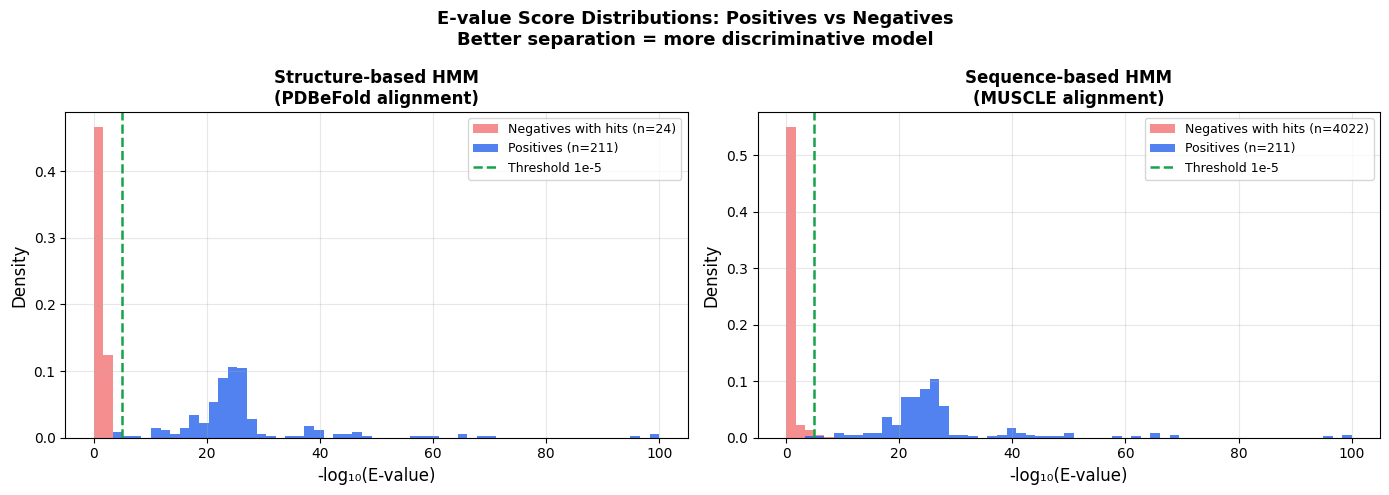

Saved: Figure_Evalue_Distributions.png


In [2]:
# Convert to -log10 for plotting (cap at 0)
def to_log(evalues, cap=1e-100):
    return [-math.log10(max(e, cap)) for e in evalues]

struct_pos_log = to_log(struct_pos)
struct_neg_log = to_log([e for e in struct_neg if e < 10])
seq_pos_log    = to_log(seq_pos)
seq_neg_log    = to_log([e for e in seq_neg if e < 10])

# Histogram plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

BINS = np.linspace(0, 100, 60)

# Structure-based
axes[0].hist(struct_neg_log, bins=BINS, color='#ef4444', alpha=0.6,
             label=f'Negatives with hits (n={len(struct_neg_log)})', density=True)
axes[0].hist(struct_pos_log, bins=BINS, color='#2563eb', alpha=0.8,
             label=f'Positives (n={len(struct_pos_log)})', density=True)
axes[0].axvline(x=5, color='#16a34a', linestyle='--', linewidth=1.8,
                label='Threshold 1e-5')
axes[0].set_xlabel('-log₁₀(E-value)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Structure-based HMM\n(PDBeFold alignment)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sequence-based
axes[1].hist(seq_neg_log, bins=BINS, color='#ef4444', alpha=0.6,
             label=f'Negatives with hits (n={len(seq_neg_log)})', density=True)
axes[1].hist(seq_pos_log, bins=BINS, color='#2563eb', alpha=0.8,
             label=f'Positives (n={len(seq_pos_log)})', density=True)
axes[1].axvline(x=5, color='#16a34a', linestyle='--', linewidth=1.8,
                label='Threshold 1e-5')
axes[1].set_xlabel('-log₁₀(E-value)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Sequence-based HMM\n(MUSCLE alignment)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('E-value Score Distributions: Positives vs Negatives\n'
             'Better separation = more discriminative model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_Evalue_Distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure_Evalue_Distributions.png')

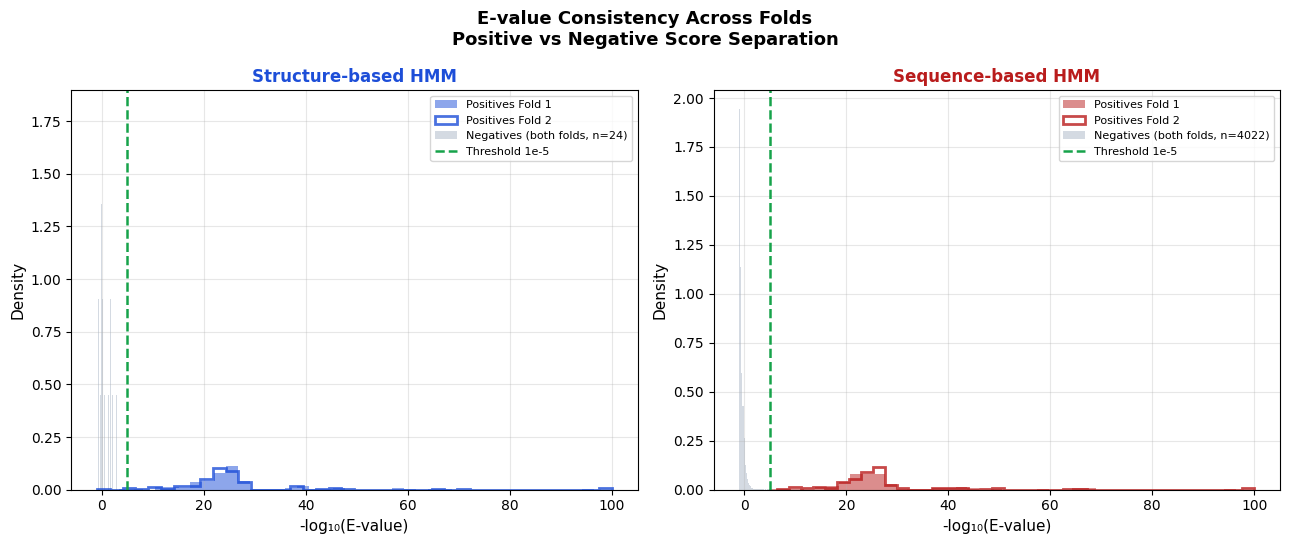

Saved: Figure_Evalue_Folds_Comparison.png


In [3]:
# Scatter plot: Fold 1 vs Fold 2 E-values (positives only)
# Shows how consistent the two models are across folds

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

EPS = 1e-100

def safe_log(evalues):
    return np.array([-math.log10(max(e, EPS)) for e in evalues])

for ax, (p1, p2, n1, n2, title, color) in zip(axes, [
    (sp1, sp2, sn1, sn2, 'Structure-based HMM', '#1d4ed8'),
    (qp1, qp2, qn1, qn2, 'Sequence-based HMM',  '#b91c1c'),
]):
    # Only sequences present in both folds — for illustration show per-sequence scores
    # Instead: plot -log10 evalue for pos (fold1) vs pos (fold2) aligned by sorted order
    p1_log = np.sort(safe_log(p1))
    p2_log = np.sort(safe_log(p2))
    n1_log = safe_log([e for e in n1 if e < 10])
    n2_log = safe_log([e for e in n2 if e < 10])

    # Histogram overlay: fold 1 vs fold 2 for positives
    ax.hist(p1_log, bins=40, color=color, alpha=0.5, label='Positives Fold 1', density=True)
    ax.hist(p2_log, bins=40, color=color, alpha=0.8, histtype='step',
            linewidth=2, label='Positives Fold 2', density=True)

    neg_all = np.concatenate([n1_log, n2_log])
    ax.hist(neg_all, bins=40, color='#94a3b8', alpha=0.4,
            label=f'Negatives (both folds, n={len(neg_all)})', density=True)

    ax.axvline(x=5, color='#16a34a', linestyle='--', linewidth=1.8, label='Threshold 1e-5')
    ax.set_xlabel('-log₁₀(E-value)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('E-value Consistency Across Folds\nPositive vs Negative Score Separation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_Evalue_Folds_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure_Evalue_Folds_Comparison.png')